In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
X = hours.reshape(-1, 1)
y = grades

hours_model = LinearRegression()
hours_model.fit(X, y)

print(f"Intercept: {hours_model.intercept_:.4f}")
print(f"Slope: {hours_model.coef_[0]:.4f}")

Intercept: 55.0355
Slope: 4.7426


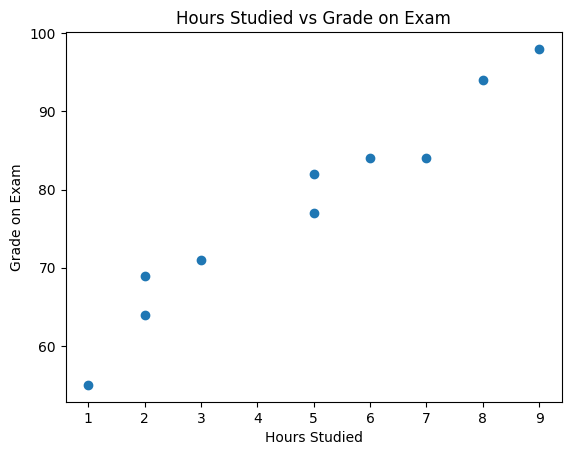

In [3]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([2, 9, 5, 5, 3, 7, 1, 8, 6, 2], dtype=float)
grades = np.array([69, 98, 82, 77, 71, 84, 55, 94, 84, 64], dtype=float)

plt.scatter(hours, grades)
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.title("Hours Studied vs Grade on Exam")
plt.show()

In [4]:
x = hours
y = grades

x_mean = x.mean()
y_mean = y.mean()

beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope (β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")

Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope (β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


In [11]:
import pandas as pd

ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [5]:
new_hours = 4
predicted_grade = beta0 + beta1 * new_hours

print(f"Predicted grade for {new_hours} hours: {predicted_grade:.2f}")

Predicted grade for 4 hours: 74.01


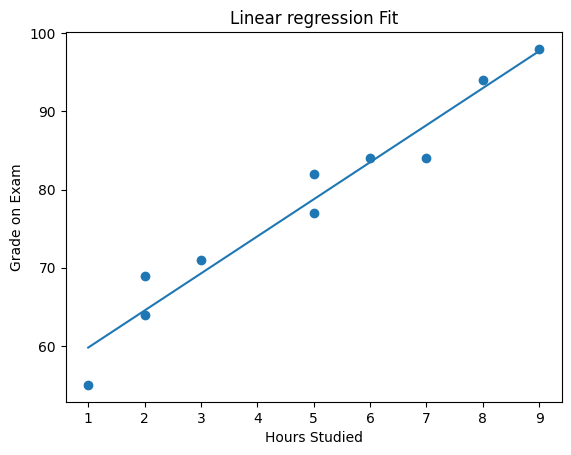

In [8]:
x_line=np.linspace(hours.min(),hours.max(),100).reshape(-1,1)
y_line=hours_model.predict(x_line)
plt.scatter(hours,grades)
plt.plot(x_line,y_line)
plt.title('Linear regression Fit')
plt.xlabel('Hours Studied')
plt.ylabel('Grade on Exam')
plt.show()

In [14]:
y_pred=hours_model.predict(X)
residuals=y-y_preed
ss_res=np.sum(residuals**2)
ss_tot=np.sum((y-y.mean())**2)
r2=1-(ss_res/ss_tot)
rmse=np.sqrt(np.mean(residuals**2))
print(f"SS_res: {ss_res:.4f}")
print(f"SS_tot: {ss_tot:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

SS_res: 79.1213
SS_tot: 1599.6000
R-squared: 0.9505
RMSE: 2.8129


## Calculation with Scikit-learn

In [15]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
r2_sklearn = r2_score(y, y_pred)
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred))

In [16]:
print(f"R-squared (sklearn): {r2_sklearn:.4f}")
print(f"RMSE (sklearn): {rmse_sklearn:.4f}")

R-squared (sklearn): 0.9505
RMSE (sklearn): 2.8129


## Business Applications

### Marketing Spend-Sales

In [18]:
import pandas as pd
ads=pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [29]:
channel_results = []

for channel in ["tv", "radio", "social_media"]:
    X_channel = ads[[channel]]
    y_sales = ads["sales"]

    channel_model = LinearRegression()
    channel_model.fit(X_channel, y_sales)

    y_hat = channel_model.predict(X_channel)

    r2_channel = r2_score(y_sales, y_hat) 
    rmse_channel = root_mean_squared_error(y_sales, y_hat)

    channel_results.append({
        "channel": channel,
        "intercept": channel_model.intercept_,
        "slope": channel_model.coef_[0],
        "r_squared": r2_channel,
        "rmse": rmse_channel
    })

pd.DataFrame(channel_results).round(4)
    

,channel,intercept,slope,r_squared,rmse
0,tv,-132.4925,3.5615,0.9990,2948.5897
1,radio,40586.8007,8.3616,0.7545,46081.4060
2,social_media,118672.5717,22.1879,0.2782,79019.9030


In [30]:
ads[['tv','radio','social_media','sales']].corr().round(3)

,tv,radio,social_media,sales
tv,1.000,0.869,0.528,0.999
radio,0.869,1.000,0.606,0.869
social_media,0.528,0.606,1.000,0.527
sales,0.999,0.869,0.527,1.000


In [33]:
import plotly.express as px
corr=ads[['tv','radio','social_media','sales']].corr().round(3)
fig=px.imshow(

    corr,
    text_auto=True,
    aspect='auto',
)
fig.update_layout(
    title='Correlation Matrix',
    xaxis_title='',
    yaxis_title='',
)
fig.show()

In [34]:
X_multi_num = ads[["tv", "radio", "social_media"]]
y_sales = ads["sales"]

multi_num_model = LinearRegression()
multi_num_model.fit(X_multi_num, y_sales)

y_hat_multi_num = multi_num_model.predict(X_multi_num)

multi_num_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi_num.columns),
    "coefficient": [multi_num_model.intercept_] + list(multi_num_model.coef_)
}).round(4)

multi_num_r2 = r2_score(y_sales, y_hat_multi_num)
multi_num_rmse = root_mean_squared_error(y_sales, y_hat_multi_num)


print(f"R-squared: {multi_num_r2:.4f}")
print(f"RMSE: {multi_num_rmse:.2f}")

R-squared: 0.9990
RMSE: 2948.54


In [35]:
multi_num_results

,feature,coefficient
0,intercept,-133.9630
1,tv,3.5626
2,radio,-0.0040
3,social_media,0.0050


In [36]:
multi_num_model.intercept_

np.float64(-133.96296784223523)

In [37]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)

X_multi = pd.get_dummies(
    ads[["tv", "radio", "social_media", "influencer"]],
    drop_first=True,
    dtype=int
)

multi_model = LinearRegression()
multi_model.fit(X_multi, y_sales)

y_hat_multi = multi_model.predict(X_multi)

multi_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi.columns),
    "coefficient": [multi_model.intercept_] + list(multi_model.coef_)
}).round(4)

multi_r2 = r2_score(y_sales, y_hat_multi)
multi_rmse = root_mean_squared_error(y_sales, y_hat_multi)

multi_results
print(f"R-squared: {multi_r2:.4f}")
print(f"RMSE: {multi_rmse:.2f}")

R-squared: 0.9990
RMSE: 2948.31


### Price-Demand

In [38]:
np.random.seed(42)
price=np.linspace(10,100,40)
demand=1200-8*price+np.random.normal(0,35,size=40)
X_price=price.reshape(-1,1)
price_model=LinearRegression()
price_model.fit(X_price,demand)
demand_pred=price_model.predict(X_price)
price_r2 = r2_score(demand, demand_pred)
price_rmse = root_mean_squared_error(demand, demand_pred)

print(f"Intercept: {price_model.intercept_:.4f}")
print(f"Slope: {price_model.coef_[0]:.4f}")
print(f"R-squared: {price_r2:.4f}")
print(f"RMSE: {price_rmse:.4f}")


Intercept: 1209.3747
Slope: -8.3096
R-squared: 0.9797
RMSE: 31.8794


### Customer Age-Revenue

In [40]:
np.random.seed(7)

age = np.random.randint(18, 66, size=50)
revenue = 18 + 2.4 * age + np.random.normal(0, 12, size=50)

X_age = age.reshape(-1, 1)

age_model = LinearRegression()
age_model.fit(X_age, revenue)

revenue_pred = age_model.predict(X_age)

age_r2 = r2_score(revenue, revenue_pred)
age_rmse = root_mean_squared_error(revenue, revenue_pred)

print(f"Intercept: {age_model.intercept_:.4f}")
print(f"Slope: {age_model.coef_[0]:.4f}")
print(f"R-squared: {age_r2:.4f}")
print(f"RMSE: {age_rmse:.4f}")

Intercept: 18.6013
Slope: 2.3835
R-squared: 0.8834
RMSE: 12.8626


## Gold Dataset

In [3]:
import pandas as pd
from os.path import join
PATH='../data/regression/time_series'

In [4]:
ts = pd.read_csv(join(PATH, 'gold_prices_2022_2023.csv'), parse_dates=['Date'])
print(ts.shape)
ts.head()

(250, 5)


,Date,Open,High,Low,Close
0,2023-04-21,"2,016.10","2,016.80","1,982.30","1,990.50"
1,2023-04-20,"2,007.70","2,024.20","2,002.20","2,019.10"
2,2023-04-19,"2,017.90","2,020.30","1,980.90","2,007.30"
3,2023-04-18,"2,007.90","2,024.60","2,003.30","2,019.70"
4,2023-04-17,"2,014.10","2,028.00","1,993.40","2,007.00"


In [5]:
import glob
import os
file_paths=glob.glob(join(PATH, '*.csv'))
file_paths

['../data/regression/time_series\\gold_prices_2022_2023.csv',
 '../data/regression/time_series\\gold_prices_2023_2024.csv',
 '../data/regression/time_series\\gold_prices_2024_2025.csv',
 '../data/regression/time_series\\gold_prices_2025_2026.csv']

In [6]:
file_names = [os.path.basename(file) for file in file_paths]
file_names

['gold_prices_2022_2023.csv',
 'gold_prices_2023_2024.csv',
 'gold_prices_2024_2025.csv',
 'gold_prices_2025_2026.csv']

In [7]:
dataframes = [pd.read_csv(file, parse_dates=['Date']) for file in file_paths]
ts_combined = pd.concat(dataframes, ignore_index=True)
print(ts_combined.shape)
ts_combined.head()

(1008, 5)


,Date,Open,High,Low,Close
0,2023-04-21,"2,016.10","2,016.80","1,982.30","1,990.50"
1,2023-04-20,"2,007.70","2,024.20","2,002.20","2,019.10"
2,2023-04-19,"2,017.90","2,020.30","1,980.90","2,007.30"
3,2023-04-18,"2,007.90","2,024.60","2,003.30","2,019.70"
4,2023-04-17,"2,014.10","2,028.00","1,993.40","2,007.00"


In [8]:
ts_combined.dtypes

Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object

In [9]:
ts_combined["Close"] = (
    ts_combined["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

ts_combined["Close"] = pd.to_numeric(ts_combined["Close"], errors="coerce")

## Visualization

In [13]:
ts_combined = ts_combined.sort_values(by='Date')

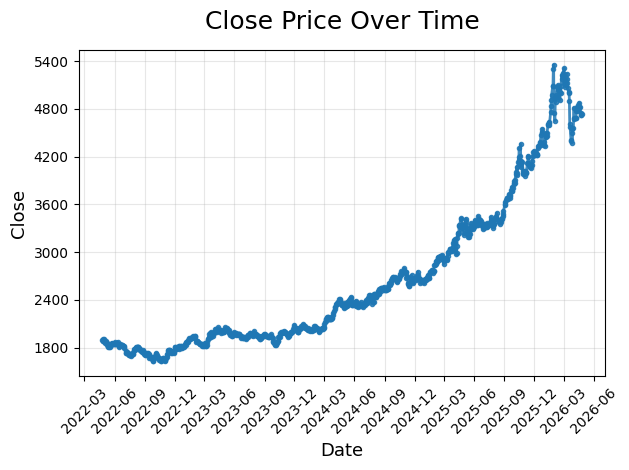

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


plt.plot(
    ts_combined["Date"],
    ts_combined["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
ts_combined['time_index']=np.arange(1,len(ts_combined)+1)
X_time=ts_combined[['time_index']]
y_time=ts_combined['Close']
trend_model=LinearRegression()
trend_model.fit(X_time,y_time)
trend_pred=trend_model.predict(X_time)
trend_r2=r2_score(y_time,trend_pred)
trend_rmse=np.sqrt(mean_squared_error(y_time,trend_pred))


In [25]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [24]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error


In [1]:
URL='https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/regression/time_series/gold_prices_2022_2023.csv'

In [27]:
print(f"Intercept: {trend_model.intercept_:.2f}")
print(f"Slope: {trend_model.coef_[0]:.4f}")
print(f"R-squared: {trend_r2:.4f}")
print(f"RMSE: {trend_rmse:.4f}")

Intercept: 1152.71
Slope: 2.9477
R-squared: 0.8247
RMSE: 395.4914
